# Modern Code

In [26]:
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
from keras.applications.mobilenet_v2 import preprocess_input

# =========================
# 1. Load Dataset (Modern Way)
# =========================
train_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/nabeelqureshitiii/doraemon-and-dorami/Doraemon and Dorami/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)

val_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/nabeelqureshitiii/doraemon-and-dorami/Doraemon and Dorami/valid",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)

import json

class_names = train_ds.class_names
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

import tensorflow as tf
from keras.applications.mobilenet_v2 import preprocess_input

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)


# =========================
# 2. Performance Optimization
# =========================
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


# =========================
# 3. Transfer learning from MobileNetV2 since our data is too small
base_model = keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# ❄️ Freeze base model
base_model.trainable = False

# =========================
# 4. Model Architecture
# =========================
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,


    # 💡 Modern trick: no Flatten headache
    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# =========================
# 5. Compile
# =========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# 6. Train
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
)

Found 28 files belonging to 2 classes.
Found 12 files belonging to 2 classes.
Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.6071 - loss: 0.6508 - val_accuracy: 1.0000 - val_loss: 0.4278
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8571 - loss: 0.4643 - val_accuracy: 1.0000 - val_loss: 0.3537
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8214 - loss: 0.3595 - val_accuracy: 0.9167 - val_loss: 0.3041
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9643 - loss: 0.1873 - val_accuracy: 0.9167 - val_loss: 0.2627
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9643 - loss: 0.1441 - val_accuracy: 0.9167 - val_loss: 0.2237
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9643 - loss: 0.1692 - val_accuracy: 1.0000 - val_loss: 0.1762
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9286 - loss: 0.1456 - val_accuracy: 1.0000 - val_loss: 0.1428
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/ste

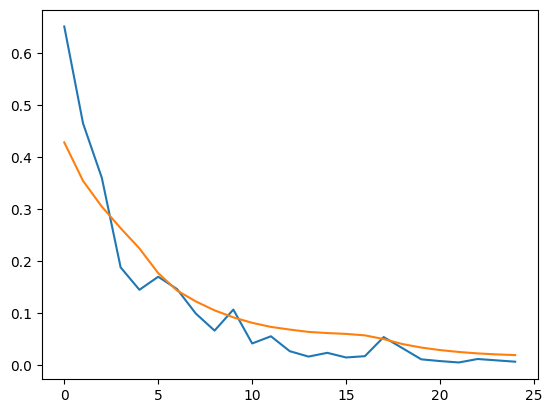

In [27]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

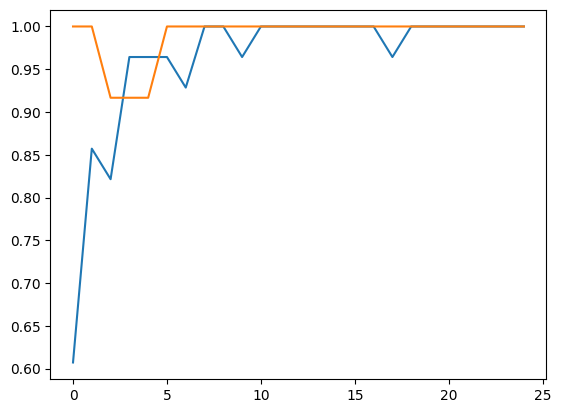

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [29]:
import cv2
dorami=cv2.imread('/kaggle/input/datasets/nabeelqureshitiii/doraemon/images.jpg')[:,:,::-1]

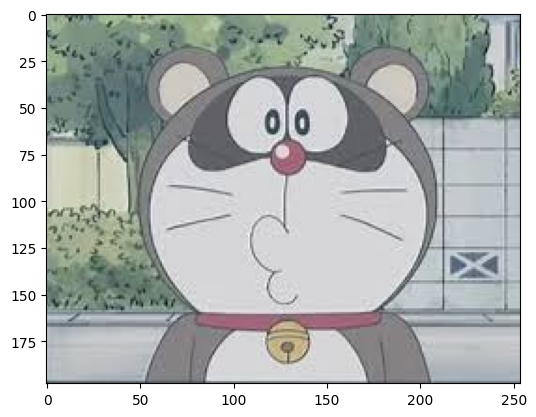

In [30]:
import matplotlib.pyplot as plt
plt.imshow(dorami)
dorami=cv2.resize(dorami,(224,224)).reshape((1,224,224,3))


In [31]:
pred = model.predict(dorami)[0][0]

if pred > 0.5:
    print(f"Predicted: {'Dorami'} ({pred:.2f})")
else:
    print(f"Predicted: {'Doraemmon'} ({1 - pred:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted: Dorami (0.53)


In [32]:
model.save("my_model.keras")

In [33]:
class_names

['Doraemon', 'Dorami']

In [36]:
import tensorflow as tf
from keras import layers
from keras.models import Sequential

train_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/nabeelqureshitiii/doraemon-and-dorami/Doraemon and Dorami/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)

val_ds = keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/nabeelqureshitiii/doraemon-and-dorami/Doraemon and Dorami/valid",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)
normalization = layers.Rescaling(1./127.5, offset=-1)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.fit(train_ds, validation_data=val_ds, epochs=25)
model.save("ogmodel.keras")


Found 28 files belonging to 2 classes.
Found 12 files belonging to 2 classes.
Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.4286 - loss: 0.9819 - val_accuracy: 0.5000 - val_loss: 0.5976
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5000 - loss: 0.9114 - val_accuracy: 1.0000 - val_loss: 0.4573
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.5714 - loss: 0.6352 - val_accuracy: 1.0000 - val_loss: 0.3556
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8571 - loss: 0.3764 - val_accuracy: 1.0000 - val_loss: 0.2846
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8571 - loss: 0.2829 - val_accuracy: 1.0000 - val_loss: 0.2343
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 1.0000 - loss: 0.1927 - val_accuracy: 1.0000 - val_loss: 0.1933
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8929 - loss: 0.2425 - val_accuracy: 1.0000 - val_loss: 0.1618
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14